In [2]:
import os
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import torch.nn.functional as F

**Root Data Directory Path**

In [3]:
data_dir = r"C:\Users\Jatin Dhiman\PycharmProjects\signatureRecognition\notebook\data"

#### Total number of classes

In [4]:
class_name = os.listdir(data_dir)
len(class_name)

2

In [5]:
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from torchvision.utils import make_grid
from torchvision import transforms as T,datasets

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device: {}".format(device))

Device: cpu


#### Transforming the data 

In [7]:
data_transform = T.Compose([
    T.Resize(size=(224, 224)),
    T.RandomRotation(degrees=(-20, +20)),
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

In [8]:
data = datasets.ImageFolder(data_dir, transform=data_transform)
total_count = len(data)

In [9]:
total_count

2640

In [10]:
print(data.class_to_idx)

{'Forged': 0, 'Original': 1}


#### Splitting the data

In [11]:
train_count = int(0.6 * total_count)
valid_count = int(0.3 * total_count)
test_count = total_count - train_count - valid_count
train_data, val_data, test_data = torch.utils.data.random_split(data, (train_count, valid_count, test_count))

In [12]:
len(train_data.indices)

1584

In [13]:
len(test_data.indices)

264

In [14]:
len(val_data.indices)

792

In [15]:
def show_image(image,label,get_denormalize = True):

    image = image.permute(1,2,0)
    mean = torch.FloatTensor([0.485, 0.456, 0.406])
    std = torch.FloatTensor([0.229, 0.224, 0.225])

    if get_denormalize == True:
        image = image*std + mean
        image = np.clip(image,0,1)
        plt.imshow(image)
        plt.title(label)

    else:
        plt.imshow(image)
        plt.title(label)

def accuracy(y_pred,y_true):
    
    y_pred = F.softmax(y_pred,dim = 1)
    top_p,top_class = y_pred.topk(1,dim = 1)
    equals = top_class == y_true.view(*top_class.shape)
    return torch.mean(equals.type(torch.FloatTensor))


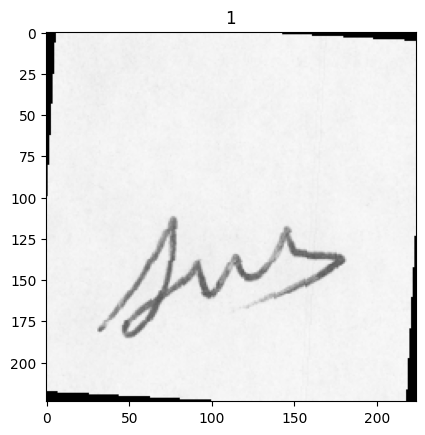

In [16]:
img, label = train_data[3]
show_image(img, label)

#### Data Loaders

In [17]:
trainloader = DataLoader(train_data, batch_size=32, shuffle=True)
print("No. of batches in trainloader:{}".format(len(trainloader)))
print("No. of Total examples:{}".format(len(trainloader.dataset)))

validationloader = DataLoader(val_data, batch_size=32, shuffle=True)
print("No. of batches in validationloader:{}".format(len(validationloader)))
print("No. of Total examples: {}".format(len(validationloader.dataset)))

testloader = DataLoader(test_data, batch_size=32, shuffle=True)
print("No. of batches in testloader:{}".format(len(testloader)))  
print("No. of Total examples:{}".format(len(testloader.dataset)))

No. of batches in trainloader:50
No. of Total examples:1584
No. of batches in validationloader:25
No. of Total examples: 792
No. of batches in testloader:9
No. of Total examples:264


#### Model

In [18]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import models
import torchvision.transforms as transforms

In [19]:
model = models.resnet34(
    weights=models.ResNet34_Weights.DEFAULT
)

In [20]:
model.fc = nn.Sequential(
    nn.Dropout(0.1),
    nn.Linear(model.fc.in_features, len(class_name))
)
model = model.to(device)

criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=1e-3, momentum=0.9)

In [21]:
def train(model, criterion, optimizer, train_dataloader, test_dataloader):

    total_train_loss = 0
    total_test_loss = 0

    # -------------------------
    # Training
    # -------------------------
    model.train()

    with tqdm(train_dataloader, unit="batch", leave=False) as pbar:
        pbar.set_description("Training")

        for images, idxs in pbar:
            images = images.to(device, non_blocking=True)
            idxs = idxs.to(device, non_blocking=True)

            output = model(images)

            loss = criterion(output, idxs)

            total_train_loss += loss.item()

            loss.backward()
            optimizer.step()
            optimizer.zero_grad(set_to_none=True)

    # -------------------------
    # Validation / Testing
    # -------------------------
    model.eval()

    with torch.no_grad():
        with tqdm(test_dataloader, unit="batch", leave=False) as pbar:
            pbar.set_description("Testing")

            for images, idxs in pbar:
                images = images.to(device, non_blocking=True)
                idxs = idxs.to(device, non_blocking=True)

                output = model(images)

                loss = criterion(output, idxs)

                total_test_loss += loss.item()

    # Average loss per batch
    train_loss = total_train_loss / len(train_dataloader)
    test_loss = total_test_loss / len(test_dataloader)

    print(
        f"Train loss: {train_loss:.4f} | "
        f"Test loss: {test_loss:.4f}"
    )

    return train_loss, test_loss

In [22]:
%%time
epochs=5
for i in range(epochs):
    print(f"Epoch {i+1}/{epochs}")
    train(model, criterion, optimizer, trainloader, validationloader)


Epoch 1/5


Train loss: 0.2357 | Test loss: 0.7579
Epoch 2/5


Train loss: 0.0194 | Test loss: 0.0039
Epoch 3/5


Train loss: 0.0236 | Test loss: 0.1011
Epoch 4/5


Train loss: 0.0095 | Test loss: 0.0416
Epoch 5/5


Train loss: 0.0075 | Test loss: 0.0014
CPU times: total: 4h 34min 25s
Wall time: 51min 21s


#### Model Saving

In [27]:
pwd

'C:\\Users\\Jatin Dhiman\\PycharmProjects\\signatureRecognition\\notebook'

In [28]:
Path = r'C:\\Users\\Jatin Dhiman\\PycharmProjects\\signatureRecognition\\notebook\\model.pt'
torch.save(model,Path)

#### Loading torch Model

In [31]:
model = torch.load(Path, weights_only=False)
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

#### Model Evaluation

In [34]:
def evaluate(model, criterion, test_dataloader):

    total_test_loss = 0

    model.eval()

    with torch.no_grad():

        with tqdm(test_dataloader, unit='batch', leave=False) as pbar:

            pbar.set_description('Testing')

            for images, idxs in pbar:

                images = images.to(device, non_blocking=True)
                idxs = idxs.to(device, non_blocking=True)

                output = model(images)

                loss = criterion(output, idxs)

                total_test_loss += loss.item()

    test_loss = total_test_loss / len(test_dataloader)

    print(f'Test loss: {test_loss:.4f}')

    return test_loss

In [35]:
evaluate(model,criterion,testloader)

Test loss: 0.0014


0.001406211713199607

#### Prediction

In [36]:
label_names = data.classes
label_names

['Forged', 'Original']

In [38]:
from PIL import Image

image = Image.open(r"C:\Users\Jatin Dhiman\PycharmProjects\signatureRecognition\notebook\data\Original\original_1_2.png")

preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
])

image = preprocess(image)

# Add batch dimension: [C, H, W] -> [1, C, H, W]
image = image.unsqueeze(0).to(device)

with torch.no_grad():
    logits = model(image)

    probs = torch.softmax(logits, dim=1)
    pred_label = torch.argmax(probs, dim=1)

print(f"Predicted label: {pred_label.item()}")

predicted_class_name = label_names[pred_label.item()]

print(f"Predicted class name: {predicted_class_name}")

Predicted label: 1
Predicted class name: Original
